# Analyse des opérations NOP

**Contexte** — `value_nop` est un compteur cumulatif d'opérations, échantillonné
à la minute. Le compteur reste constant pendant qu'une opération est en cours,
puis change de valeur au passage à l'opération suivante : une opération
correspond donc à un plateau de valeur constante.

**Objectif** — caractériser la durée des opérations, identifier les meilleures
séries consécutives (3, 5, 7, ... opérations), en déduire une capacité
journalière équivalente, et suivre l'évolution de cette performance dans le
temps (amélioration ou dégradation mois par mois).

**Méthodologie** — toute la logique métier est implémentée dans le package
`nop_analysis/` (nettoyage, extraction, KPI, scoring). Ce notebook ne fait
qu'appeler ces fonctions et interpréter les résultats.


In [38]:
%load_ext autoreload
%autoreload 2

import pandas as pd

from tools.OI_class_OP import OI_DataProcessor
import nop_analysis as nopa
from nop_analysis import plots, config

pd.set_option('display.max_columns', None)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Chargement des données

Les données sont extraites via le processeur de production `OI_DataProcessor`,
qui interroge l'API OIAnalytics et calcule les bilans par produit.


In [39]:
tags = [
    {'tag': 'NOP_ESTERS', 'nom': 'value_nop', 'info': "Nombre des opérations", 'agg': 'FIRST'},
]

processor = OI_DataProcessor(
    url_base='https://oianalytics-100.optimistik.fr/api/oianalytics/time-values/query?',
    start='2016-01-01',
    end='2026-12-31',
    tags_selected=tags,
    tags_other=[],
    interval='PT01M',
    verbose=False,
    agg='FIRST'
)

processor.merge()
processor.data.describe()


,value_nop
count,5.509669e+06
mean,8.721022e+02
std,5.888953e+02
min,0.000000e+00
25%,3.390000e+02
50%,7.980000e+02
75%,1.346000e+03
max,2.272000e+03


## 2. Nettoyage

`nop_analysis.clean_dataframe` applique, de façon vectorisée et validée :

- suppression des lignes sans valeur (`NaN`)
- suppression des valeurs négatives (capteur invalide)
- conversion en entier (`int64`) — le compteur est par nature un entier
- tri chronologique

Cette étape est également exécutée automatiquement à l'intérieur de
`extract_operations` (section suivante) ; elle est montrée ici séparément à
titre de contrôle.


In [40]:
clean = nopa.clean_dataframe(processor.data, value_col=config.VALUE_COLUMN)
print(f"Lignes brutes      : {len(processor.data):,}")
print(f"Lignes après nettoyage : {len(clean):,}")
clean.describe()


Lignes brutes      : 5,526,375
Lignes après nettoyage : 5,509,669


,value_nop
count,5.509669e+06
mean,8.721022e+02
std,5.888953e+02
min,0.000000e+00
25%,3.390000e+02
50%,7.980000e+02
75%,1.346000e+03
max,2.272000e+03


## 3. Reconstruction des opérations

Une opération = un plateau de valeur constante du compteur. Sa durée est le
temps écoulé jusqu'au début du plateau suivant.

On écarte ensuite les opérations dont la durée est hors de
`[MIN_OPERATION_DURATION, MAX_OPERATION_DURATION]` — un signal trop court
correspond généralement à du bruit capteur, un signal trop long à un arrêt de
ligne prolongé, ni l'un ni l'autre n'étant représentatif d'une opération
normale.


In [41]:
ops = nopa.extract_operations(processor.data, value_col=config.VALUE_COLUMN)
print(f"Opérations détectées avant filtrage : {len(ops):,}")

ops = nopa.filter_operations_by_duration(
    ops,
    min_duration=config.MIN_OPERATION_DURATION,
    max_duration=config.MAX_OPERATION_DURATION,
)

ops.describe()


Opérations détectées avant filtrage : 9,441
Opérations conservées : 8,928 / 9,441 (rejetées : 513 — hors [0 days 05:00:00, 1 days 00:00:00])


,operation_id,value,duration,duration_min,n_samples
count,8928.000000,8928.000000,8928,8928.000000,8928.000000
mean,4700.053987,927.040211,0 days 07:56:58.467741935,476.974462,475.623208
std,2745.759467,569.482010,0 days 02:37:49.179019226,157.819650,157.292533
min,1.000000,1.000000,0 days 05:00:00,300.000000,147.000000
25%,2321.750000,465.000000,0 days 06:29:00,389.000000,388.000000
50%,4641.500000,854.000000,0 days 07:05:00,425.000000,424.000000
75%,7102.250000,1381.000000,0 days 08:22:00,502.000000,501.000000
max,9440.000000,2272.000000,0 days 23:59:00,1439.000000,1439.000000


## 4. Analyse statistique

Distribution des durées (avec zoom sur la masse principale et panneau de
stats), puis durée par jour de la semaine — plus pertinent qu'une répartition
par identifiant d'opération, qui n'apparaît qu'une seule fois par valeur et ne
montrerait donc aucune dispersion.


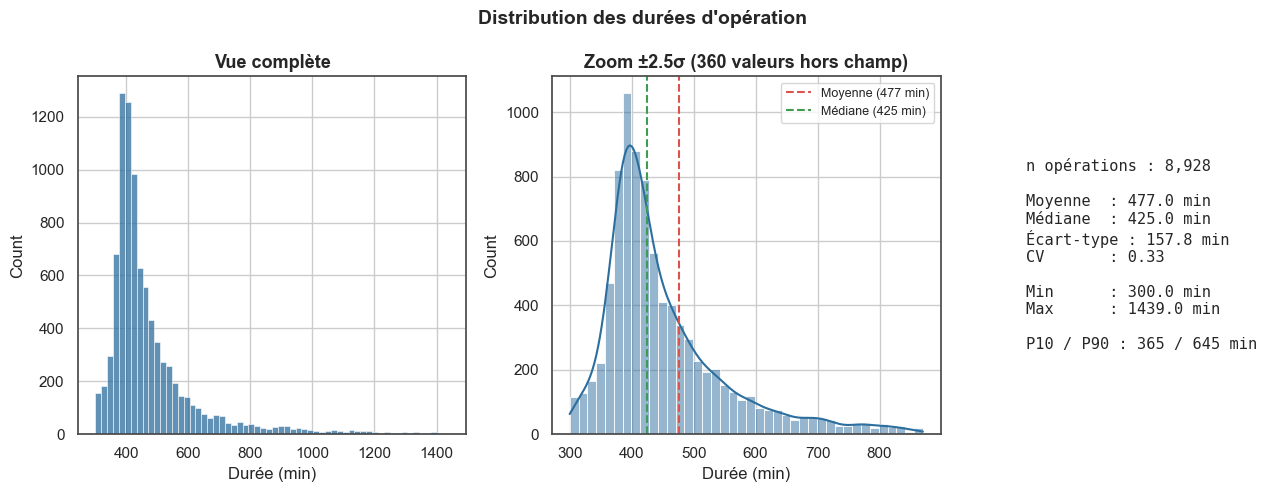

In [42]:
plots.plot_duration_histogram(ops)


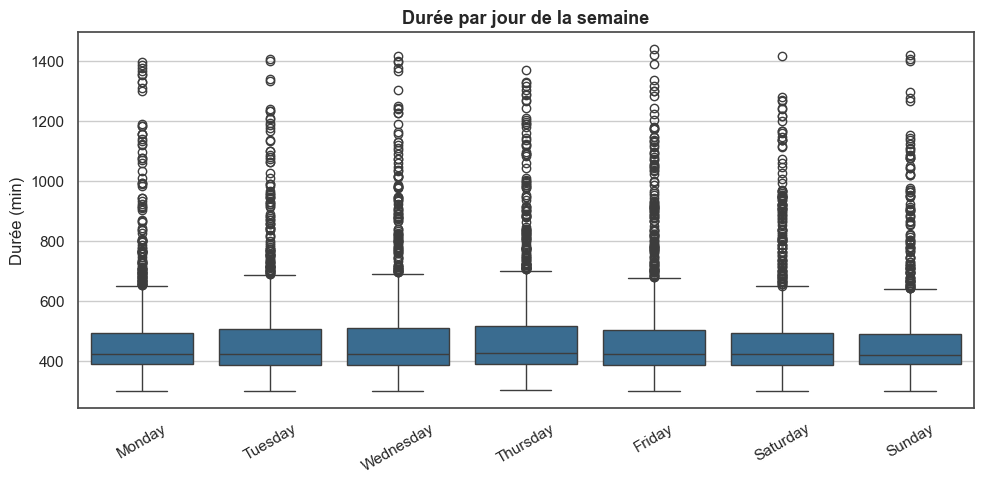

In [43]:
plots.plot_duration_by_weekday(ops)


### Meilleures séries consécutives

Pour chaque taille de fenêtre testée, on cherche la séquence d'opérations
consécutives dont la durée totale est minimale, et on en déduit la capacité
journalière équivalente (`ops_per_day = window / total_duration_min * 1440`).

Le détail visuel de la séquence retenue comme référence (fenêtre
`GOLDEN_RUN_WINDOW`) est présenté une seule fois, dans le dashboard du golden
run ci-dessous, plutôt que d'être dupliqué ici.


In [44]:
results = nopa.analyze_best_runs(ops, window_sizes=config.DEFAULT_WINDOW_SIZES)

for w, r in results.items():
    print(f"--- Fenêtre {w} opérations ---")
    print(f"  Période            : {r['start_time']} -> {r['end_time']}")
    print(f"  Durée totale (min) : {r['total_duration_min']:.1f}")
    print(f"  Durée moyenne (min): {r['mean_duration_min']:.1f}")
    print(f"  Coefficient de variation : {r['cv']:.2f}")
    print(f"  Capacité équivalente     : {r['capacity_per_day']:.2f} ops/jour")
    print()


--- Fenêtre 9 opérations ---
  Période            : 2022-03-04 03:33:00+00:00 -> 2022-03-06 14:57:00+00:00
  Durée totale (min) : 3003.0
  Durée moyenne (min): 333.7
  Coefficient de variation : 0.08
  Capacité équivalente     : 4.32 ops/jour

--- Fenêtre 15 opérations ---
  Période            : 2022-03-04 03:33:00+00:00 -> 2022-03-08 15:14:00+00:00
  Durée totale (min) : 5143.0
  Durée moyenne (min): 342.9
  Coefficient de variation : 0.11
  Capacité équivalente     : 4.20 ops/jour

--- Fenêtre 25 opérations ---
  Période            : 2022-03-28 06:55:00+00:00 -> 2022-04-09 18:05:00+00:00
  Durée totale (min) : 8746.0
  Durée moyenne (min): 349.8
  Coefficient de variation : 0.13
  Capacité équivalente     : 4.12 ops/jour

--- Fenêtre 35 opérations ---
  Période            : 2022-02-26 06:21:00+00:00 -> 2022-03-08 20:54:00+00:00
  Durée totale (min) : 12835.0
  Durée moyenne (min): 366.7
  Coefficient de variation : 0.11
  Capacité équivalente     : 3.93 ops/jour

--- Fenêtre 50 opéra

## 5. Golden Run

Le "golden run" est calculé sur une taille de fenêtre fixe (35 opérations par
défaut, `config.GOLDEN_RUN_WINDOW`) — c'est la meilleure séquence de 35
opérations consécutives observée sur toute la période.

La comparaison visuelle multi-fenêtres du dashboard (`comparison_window_sizes`)
est volontairement découplée de ce choix : on peut comparer le golden run à
d'autres tailles de fenêtre sans changer la référence elle-même.


In [45]:
golden = nopa.golden_run(ops, window=config.GOLDEN_RUN_WINDOW)

print(f"Fenêtre golden run : {golden['window']} opérations")
print(f"Capacité équivalente : {golden['result']['capacity_per_day']:.2f} ops/jour")


Fenêtre golden run : 35 opérations
Capacité équivalente : 3.93 ops/jour


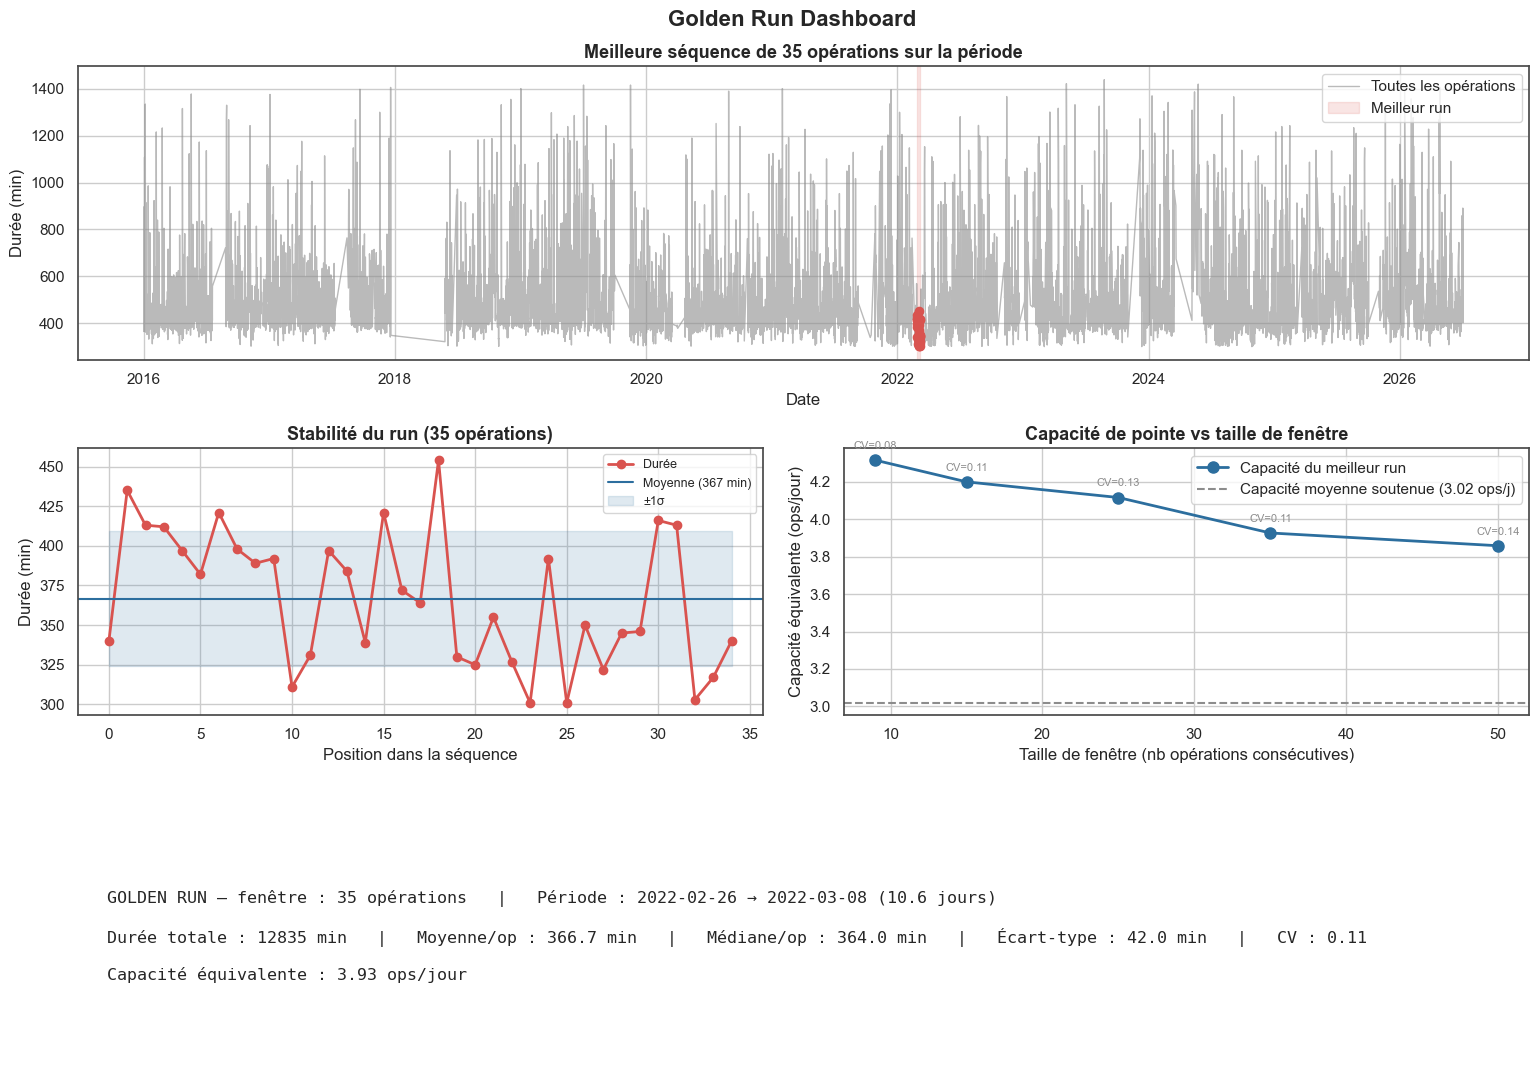

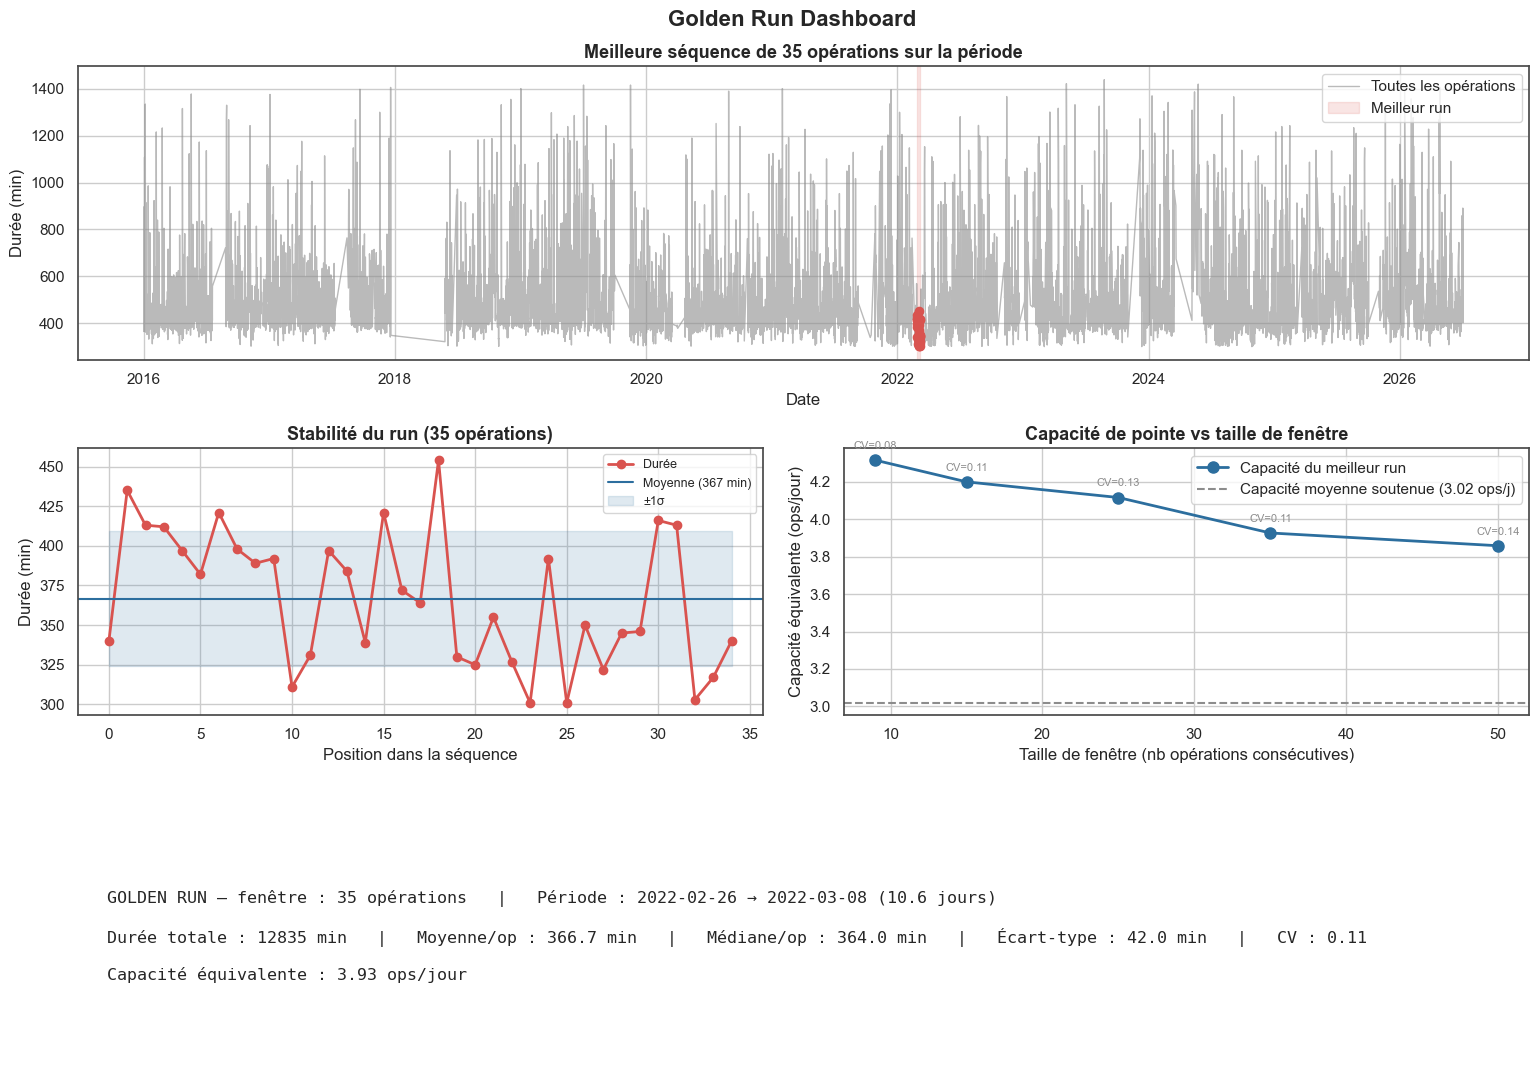

In [46]:
nopa.golden_run_dashboard(ops, golden, comparison_window_sizes=config.DEFAULT_WINDOW_SIZES)


## 6. Capacité vs taille de fenêtre, et évolution dans le temps

Deux vues complémentaires, plus lisibles que des heatmaps sur ce type de
données :

- **Capacité vs taille de fenêtre** : montre l'effet de "régression vers la
  moyenne" — plus la fenêtre est longue, plus la capacité de pointe se
  rapproche de la capacité moyenne soutenue. Aide à juger si une fenêtre
  donnée capture un sprint ponctuel ou une performance soutenable.
- **Capacité glissante dans le temps** : contrairement à une heatmap globale,
  cette vue a un axe temporel exploitable pour repérer visuellement une
  tendance ou une rupture.


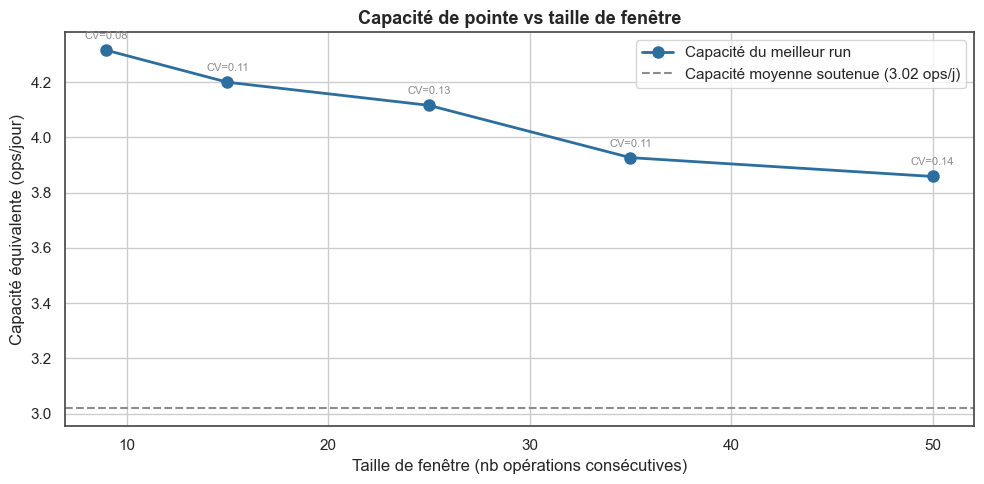

In [47]:
plots.plot_capacity_vs_window(results, ops)


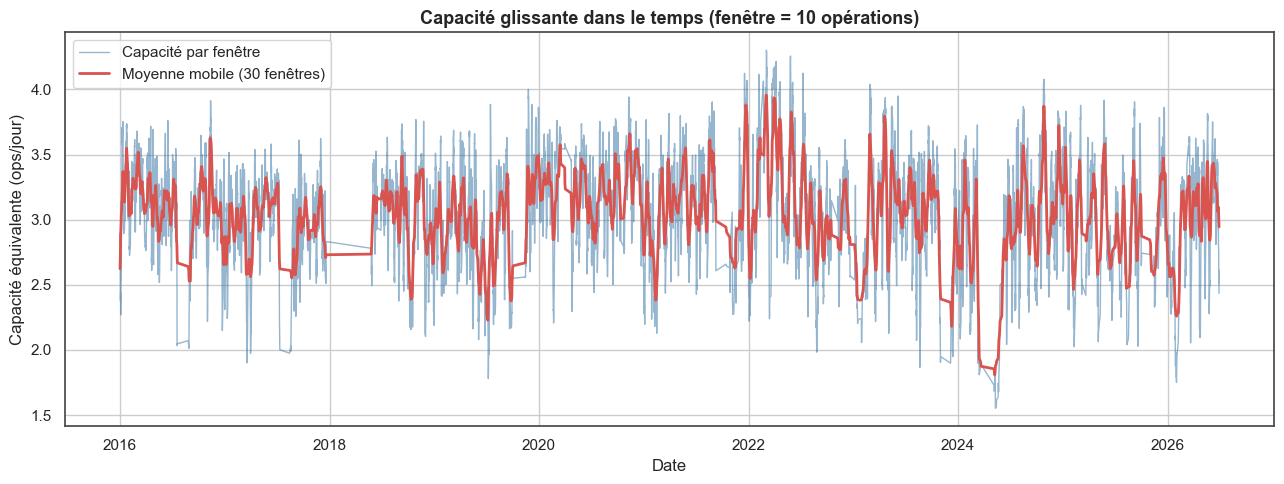

In [48]:
plots.plot_rolling_capacity_over_time(ops, window=config.MONTHLY_ROLLING_WINDOW)


## 7. KPI mensuels

Deux angles complémentaires pour suivre la tendance mois par mois :

- **Z-score (vue principale)** : compare chaque mois à la distribution de
  *toutes* les fenêtres glissantes — la vue la plus fiable pour juger d'une
  amélioration ou dégradation progressive.
- **Score (vue secondaire)** : `référence / durée`, référence = meilleure
  séquence jamais observée. Répond à "à quel point suis-je loin du record ?",
  pas à "est-ce que je progresse ?" — à interpréter avec prudence pour la
  tendance, car un seul mois record écrase visuellement tous les autres.


In [49]:
zscored = nopa.compute_zscore(ops, window=config.GOLDEN_RUN_WINDOW)
monthly_zscore = nopa.compute_monthly_zscore(zscored)
monthly_zscore


,month,mean_z,median_z,std_z,best_z,worst_z,n_runs
0,2016-01,0.663487,0.606194,0.433730,1.541936,-0.166304,96
1,2016-02,0.748506,0.722665,0.362901,1.465511,0.083145,83
2,2016-03,0.628531,0.645629,0.346563,1.475293,0.083145,87
3,2016-04,0.459885,0.509288,0.377587,1.079720,-0.292252,92
4,2016-05,-0.059434,0.026897,0.400678,0.816209,-0.950114,94
...,...,...,...,...,...,...,...
116,2026-02,-0.055304,0.123497,0.709740,0.670697,-2.394842,67
117,2026-03,0.015826,-0.036688,0.476121,0.737950,-0.767306,75
118,2026-04,0.072442,0.255559,0.604549,1.003296,-0.892031,87
119,2026-05,0.191791,0.108212,0.497885,1.213005,-0.590002,94


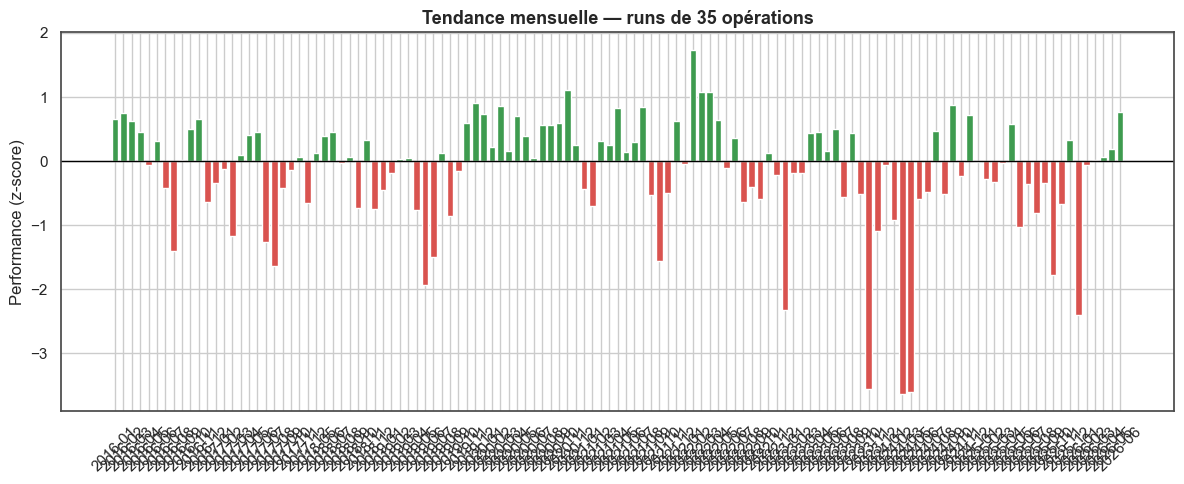

In [50]:
plots.plot_monthly_zscore(monthly_zscore, window=config.GOLDEN_RUN_WINDOW)


In [51]:
monthly_scores = nopa.compute_monthly_scores(ops, window=config.MONTHLY_ROLLING_WINDOW)
monthly_scores


,month,mean_score,median_score,best_score,worst_score,n_sequences
0,2016-01,0.753017,0.748411,0.872557,0.527743,96
1,2016-02,0.745331,0.745325,0.855610,0.633971,83
2,2016-03,0.762428,0.769301,0.843113,0.642487,87
3,2016-04,0.738406,0.742437,0.864446,0.607072,92
4,2016-05,0.706853,0.699912,0.811047,0.585724,94
...,...,...,...,...,...,...
116,2026-02,0.686662,0.725932,0.774104,0.407299,67
117,2026-03,0.711159,0.752529,0.846309,0.477535,75
118,2026-04,0.714751,0.725146,0.843113,0.486840,87
119,2026-05,0.725119,0.745830,0.886887,0.529831,94


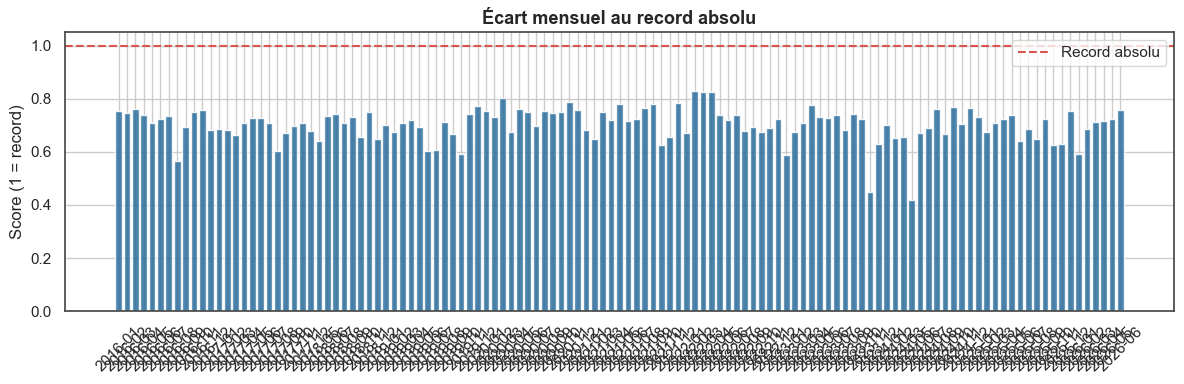

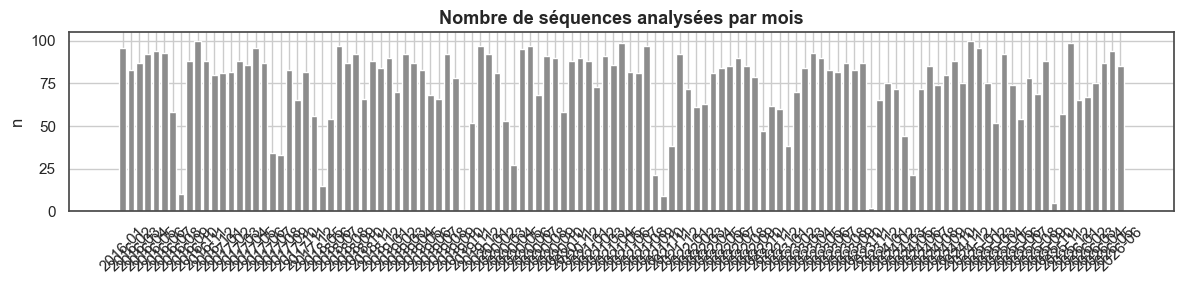

In [52]:
plots.plot_monthly_score(monthly_scores)
plots.plot_monthly_sequence_count(monthly_scores)


## 8. Conclusions

La synthèse ci-dessous est générée automatiquement à partir des résultats
calculés dans ce notebook (`nopa.build_summary_report`) — elle se met donc à
jour d'elle-même à chaque nouvelle exécution.


In [53]:
from IPython.display import Markdown, display

summary = nopa.build_summary_report(
    ops=ops,
    results=results,
    golden=golden,
    monthly_scores=monthly_scores,
    monthly_zscore=monthly_zscore,
)

display(Markdown(summary))


### Résultats

- Nombre d'opérations analysées : **8,928**
- Durée moyenne : **477.0 min** (7.95 h)
- Durée médiane : **425.0 min**
- Durée min / max : **300.0 min** / **1439.0 min**
- Écart-type : **157.8 min**

**Meilleures séries consécutives :**

- Fenêtre de 9 opérations : 3003.0 min au total (2022-03-04 03:33 → 2022-03-06 14:57) → capacité équivalente **4.32 ops/jour**
- Fenêtre de 15 opérations : 5143.0 min au total (2022-03-04 03:33 → 2022-03-08 15:14) → capacité équivalente **4.20 ops/jour**
- Fenêtre de 25 opérations : 8746.0 min au total (2022-03-28 06:55 → 2022-04-09 18:05) → capacité équivalente **4.12 ops/jour**
- Fenêtre de 35 opérations : 12835.0 min au total (2022-02-26 06:21 → 2022-03-08 20:54) → capacité équivalente **3.93 ops/jour**
- Fenêtre de 50 opérations : 18660.0 min au total (2022-02-21 14:09 → 2022-03-08 15:14) → capacité équivalente **3.86 ops/jour**

**Golden run** (fenêtre de référence : 35 opérations) : capacité équivalente **3.93 ops/jour**, sur **10.6 jours**, coefficient de variation **0.11**.

### Maille de référence pour l'OEE

- Pour le **débit/capacité**, c'est la **moyenne** qui doit servir de référence (capacité = 1440 / durée moyenne) — la médiane ne reconstitue pas le temps total écoulé.
- Écart moyenne/médiane sur ce run : **0.7%** — proches, run homogène.
- La fenêtre de 35 opérations couvre **10.6 jours** sur ce run — **pas exactement 7 jours** ici : si une maille hebdomadaire est visée, ajuster la taille de fenêtre (`config.GOLDEN_RUN_WINDOW`) plutôt que de supposer que 35 = 7 jours.
- run homogène (CV < 0.15) : moyenne et médiane doivent être proches, référence fiable.
- Aucune opération atypique détectée à l'intérieur du run par rapport à la distribution globale.
- Recommandation générale : le **minimum absolu** est un extrême par construction (référence structurellement optimiste). Pour une référence OEE soutenable, préférer le **10ᵉ percentile** des fenêtres glissantes de même taille (`build_sliding_windows` + `.quantile(0.1)`) plutôt que le record.

### Tendance

**Tendance mensuelle (z-score, indicateur principal)** : dégradation (pente = -0.0040 / mois)
**Écart au record (score, indicateur secondaire)** : dégradation (pente = -0.0002 / mois)

- Période couverte : **2016-01** → **2026-06**
- Meilleur mois (score moyen) : **2022-02** (score = 0.828)
- Mois le plus faible (score moyen) : **2024-05** (score = 0.420)

### Interprétation

Le z-score indique une **dégradation** de la performance dans le temps — à surveiller.

### Limites

- Le filtre de durée `[MIN_OPERATION_DURATION, MAX_OPERATION_DURATION]`
  (actuellement [0h, 24h]) écarte les arrêts de ligne prolongés mais reste un
  choix à valider métier si un nouveau type d'anomalie apparaît.
- La résolution d'échantillonnage (1 minute) limite la précision temporelle
  des transitions entre opérations.

### Perspectives

- Basculer la référence OEE du record absolu vers un percentile (ex: P10) des
  fenêtres glissantes, moins sensible à un coup de chance ponctuel (cf.
  section "Maille de référence pour l'OEE" ci-dessus).
- Croiser la performance mensuelle avec des événements connus (maintenance,
  changement d'équipe, saisonnalité) pour expliquer les variations observées.
